# Configuration & Environment Setup



In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
import copy
import scipy.stats

# File path for the dataset
FILE_PATH = '../data/df_fuel_ckan.csv'

# Verify dataset exists before proceeding
if os.path.exists(FILE_PATH):
    print(f"[INFO] Dataset located successfully at: {FILE_PATH}")
else:
    raise FileNotFoundError(
        f"[ERROR] Dataset not found at {FILE_PATH}\n"
        "Please ensure 'df_fuel_ckan.csv' is placed in the 'data/' directory before running the simulation."
    )

# Suppress warnings & Set Style
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    # --- Resolution & canvas ---
    'figure.dpi'            : 600,       
    'figure.figsize'        : (16, 8),   

    # --- Typography ---
    'font.family'           : 'DejaVu Sans',
    'font.size'             : 18,
    'axes.titlesize'        : 20,
    'axes.titleweight'      : 'bold',
    'axes.labelsize'        : 18,
    'xtick.labelsize'       : 15,
    'ytick.labelsize'       : 15,
    'legend.fontsize'       : 15,
    'legend.title_fontsize' : 15,

    # --- Lines & markers ---
    'lines.linewidth'       : 3,
    'lines.markersize'      : 9,

    # --- Spines & grid ---
    'axes.spines.top'       : False,
    'axes.spines.right'     : False,
    'grid.alpha'            : 0.4,
})


[INFO] Dataset located successfully at: ../data/df_fuel_ckan.csv


# Data Loader

In [17]:
# Define a class to handle grid data loading and synthetic data generation incase of missing or malformed CSV
class GridDataLoader:

    def __init__(self, file_path=None):
        self.file_path = file_path
        self.raw_data = None

    def load_or_generate_data(self):

        if self.file_path:
            try:
                self._load_csv()
            except Exception as e:
                print(f"[Error] Failed to load CSV: {e}")
                print("[Info] Switching to Synthetic Data Generation.")
                self._generate_synthetic_uk_data()
        else:
            self._generate_synthetic_uk_data()

        return self.raw_data

    def _load_csv(self):

        df = pd.read_csv(self.file_path)

        df.columns = [c.lower().strip() for c in df.columns]

        time_col = next((c for c in df.columns if 'date' in c or 'time' in c), None)
        int_col = next((c for c in df.columns if 'carbon' in c or 'intensity' in c), None)

        if not time_col or not int_col:
            raise ValueError("CSV must contain timestamp and intensity columns.")

        df = df.rename(columns={time_col: 'timestamp', int_col: 'carbon_intensity'})

        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

        df.set_index('timestamp', inplace=True)

        df.sort_index(inplace=True)

        self.raw_data = df

        print(f"Loaded {len(df)} rows from CSV.")
    
    
    # Synthetic data generation for UK grid carbon intensity with realistic patterns, spikes, and gaps
    def _generate_synthetic_uk_data(self):

        dates = pd.date_range(start='2024-01-01', periods=48*14, freq='30T')

        n = len(dates)

        diurnal = 50 * np.sin(np.linspace(0, 14 * 2 * np.pi, n))
        weather = 100 * np.sin(np.linspace(0, 4 * 2 * np.pi, n))

        baseline = 200

        noise = np.random.normal(0, 10, n)

        ci = baseline + diurnal + weather + noise

        spike_indices = np.random.choice(n, 10, replace=False)

        ci[spike_indices[:5]] = 800
        ci[spike_indices[5:]] = -50

        gap_indices = np.random.choice(n, 20, replace=False)

        ci[gap_indices] = np.nan

        self.raw_data = pd.DataFrame({'carbon_intensity': ci}, index=dates)

        print("Synthetic grid data generated.")


# Data Cleaning


In [18]:
# Define a class to handle robust cleaning of carbon intensity data, including outlier detection and interpolation
class RobustCleaner:

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def clean(self):

        self.df = self.df.resample('30T').asfreq()

        self.df.loc[self.df['carbon_intensity'] < 0, 'carbon_intensity'] = np.nan

        mu = self.df['carbon_intensity'].mean()
        sigma = self.df['carbon_intensity'].std()

        z_scores = (self.df['carbon_intensity'] - mu) / sigma

        outliers = np.abs(z_scores) > 3

        self.df.loc[outliers, 'carbon_intensity'] = np.nan

        self.df['carbon_intensity'] = (
            self.df['carbon_intensity']
            .interpolate(method='time')
            .ffill()
            .bfill()
        )

        print("Cleaning pipeline complete.")

        return self.df


# Task Model


In [19]:
# Define a class to represent individual tasks with their attributes and constraints
class Task:

    def __init__(self, task_id, arrival_time, duration_slots, power_kw, max_delay_slots):

        self.id = task_id
        self.arrival_time = arrival_time

        self.duration = int(duration_slots)

        self.power = float(power_kw)

        self.deadline = arrival_time + timedelta(minutes=30 * int(max_delay_slots))


# Carbon Aware Scheduler

In [20]:
# Define a class to implement the carbon-aware scheduling algorithm based on the cleaned grid data and task list
class CarbonAwareScheduler:

    def __init__(self, grid_df, percentile_threshold=40):

        self.grid = grid_df

        self.threshold = np.percentile(self.grid['carbon_intensity'], percentile_threshold)

        print(f"Green Threshold: {self.threshold:.2f} gCO2/kWh")

    def schedule(self, task_list):

        results = []

        queue = []

        timeline = self.grid.index

        incoming = sorted(task_list, key=lambda x: x.arrival_time)

        for current_time in timeline:

            current_ci = self.grid.loc[current_time, 'carbon_intensity']

            while incoming and incoming[0].arrival_time <= current_time:
                queue.append(incoming.pop(0))

            for task in queue[:]:

                is_green = current_ci <= self.threshold

                time_left = task.deadline - current_time

                time_needed = timedelta(minutes=30 * task.duration)

                must_start = time_left <= time_needed

                if is_green or must_start:

                    self._execute_task(task, current_time)

                    results.append(task)

                    queue.remove(task)

        return results
    # Core logic to execute a task, calculate its finish time, carbon emissions, and waiting time based on the grid data
    def _execute_task(self, task, start_time):

        task.start_time = start_time

        start_idx = self.grid.index.get_indexer([start_time])[0]

        end_idx = start_idx + task.duration

        if end_idx > len(self.grid):
            end_idx = len(self.grid)

        window = self.grid.iloc[start_idx:end_idx]

        task.finish_time = start_time + timedelta(minutes=30 * len(window))

        avg_ci = window['carbon_intensity'].mean()

        hours = len(window) * 0.5

        task.carbon_emitted = task.power * hours * avg_ci

        task.waited_hours = (start_time - task.arrival_time).total_seconds() / 3600.0

        task.execution_ci = avg_ci


# Workload Generation

In [21]:
# Function to generate a random workload of tasks with realistic arrival patterns, durations, power requirements, and deadlines based on the grid data
def generate_random_workload(df, n_tasks=200):
    # Seeding is delegated to the caller so each Monte Carlo run receives
    # an independently seeded workload via np.random.seed(run_index).

    tasks = []

    max_idx = len(df) - 96

    arrival_indices = np.random.randint(0, max_idx, size=n_tasks)

    durations = np.random.exponential(scale=4.0, size=n_tasks)
    durations = np.clip(np.round(durations), 1, 48).astype(int)

    powers = np.random.normal(loc=10.0, scale=3.0, size=n_tasks)
    powers = np.clip(powers, 1.0, 50.0)

    # SLA delay tolerance sampled from Exponential(scale=24) and clipped to
    # [24, 144] slots (12-72 hrs). The lower bound ensures every task has
    # sufficient deferral slack relative to its expected duration, preserving
    # the scheduler's ability to defer tasks to low-carbon windows.
    delays = np.random.exponential(scale=24.0, size=n_tasks)
    delays = np.clip(np.round(delays), 24, 144).astype(int)

    for i in range(n_tasks):

        arrival = df.index[arrival_indices[i]]

        tasks.append(Task(i, arrival, durations[i], powers[i], delays[i]))

    return tasks


# Main Execution

In [22]:
# Main execution block: 30-run Monte Carlo loop comparing baseline and PBTS schedulers
if __name__ == "__main__":

    print("Starting Simulation")

    loader = GridDataLoader(FILE_PATH)

    raw_df = loader.load_or_generate_data()

    clean_df = RobustCleaner(raw_df).clean()

    # --- 30 independent runs with dynamic seeding ---
    reduction_results = []

    for i in range(30):

        np.random.seed(i)

        workload = generate_random_workload(clean_df, n_tasks=250)

        total_tasks = len(workload)

        print(f"\n[Run {i}] Running Baseline Scheduler")

        results_naive = CarbonAwareScheduler(clean_df, 100).schedule(copy.deepcopy(workload))

        print(f"[Run {i}] Running Smart Scheduler")

        results_smart = CarbonAwareScheduler(clean_df, 30).schedule(copy.deepcopy(workload))

        total_carbon_naive = sum(t.carbon_emitted for t in results_naive)
        total_carbon_smart = sum(t.carbon_emitted for t in results_smart)

        if total_carbon_naive > 0:
            savings = (1 - total_carbon_smart / total_carbon_naive) * 100
        else:
            savings = 0

        avg_wait_baseline = np.mean([t.waited_hours for t in results_naive])
        avg_wait_smart    = np.mean([t.waited_hours for t in results_smart])

        avg_ci_baseline = np.mean([t.execution_ci for t in results_naive])
        avg_ci_smart    = np.mean([t.execution_ci for t in results_smart])

        completion_baseline = len(results_naive) / total_tasks * 100
        completion_smart    = len(results_smart)  / total_tasks * 100

        print(f"\n[Run {i}] SIMULATION RESULTS")
        print(f"Total Carbon (Baseline):   {total_carbon_naive:,.2f} gCO2")
        print(f"Total Carbon (Smart):      {total_carbon_smart:,.2f} gCO2")
        print(f"Reduction Achieved:        {savings:.2f}%")

        print("\nLatency Comparison")
        print(f"Average Wait (Baseline):   {avg_wait_baseline:.2f} hours")
        print(f"Average Wait (Smart):      {avg_wait_smart:.2f} hours")

        print("\nCarbon Intensity of Execution Windows")
        print(f"Baseline CI:               {avg_ci_baseline:.2f} gCO2/kWh")
        print(f"Smart CI:                  {avg_ci_smart:.2f} gCO2/kWh")

        print("\nTask Completion Rate")
        print(f"Baseline Completion:       {completion_baseline:.1f}%")
        print(f"Smart Completion:          {completion_smart:.1f}%")

        baseline_co2 = total_carbon_naive
        pbts_co2     = total_carbon_smart
        pct_reduction = ((baseline_co2 - pbts_co2) / baseline_co2) * 100
        reduction_results.append(pct_reduction)

        results_naive.sort(key=lambda x: x.start_time)
        results_smart.sort(key=lambda x: x.start_time)

        cum_naive = np.cumsum([t.carbon_emitted for t in results_naive])
        cum_smart = np.cumsum([t.carbon_emitted for t in results_smart])

    # --- Statistical summary across all 30 runs ---
    mean_reduction = np.mean(reduction_results)
    sem = scipy.stats.sem(reduction_results)
    ci_low, ci_high = scipy.stats.t.interval(
        0.95,
        df=len(reduction_results) - 1,
        loc=mean_reduction,
        scale=sem
    )
    print(f"\nMean Carbon Reduction: {mean_reduction:.2f}%, 95% Confidence Interval: [{ci_low:.2f}%, {ci_high:.2f}%]")


Starting Simulation
Loaded 299726 rows from CSV.
Cleaning pipeline complete.

[Run 0] Running Baseline Scheduler
Green Threshold: 644.00 gCO2/kWh
[Run 0] Running Smart Scheduler
Green Threshold: 187.00 gCO2/kWh

[Run 0] SIMULATION RESULTS
Total Carbon (Baseline):   1,465,409.07 gCO2
Total Carbon (Smart):      1,461,520.74 gCO2
Reduction Achieved:        0.27%

Latency Comparison
Average Wait (Baseline):   0.00 hours
Average Wait (Smart):      9.70 hours

Carbon Intensity of Execution Windows
Baseline CI:               295.51 gCO2/kWh
Smart CI:                  293.33 gCO2/kWh

Task Completion Rate
Baseline Completion:       100.0%
Smart Completion:          100.0%

[Run 1] Running Baseline Scheduler
Green Threshold: 644.00 gCO2/kWh
[Run 1] Running Smart Scheduler
Green Threshold: 187.00 gCO2/kWh

[Run 1] SIMULATION RESULTS
Total Carbon (Baseline):   1,537,256.03 gCO2
Total Carbon (Smart):      1,535,629.55 gCO2
Reduction Achieved:        0.11%

Latency Comparison
Average Wait (Baseline

# Visualization


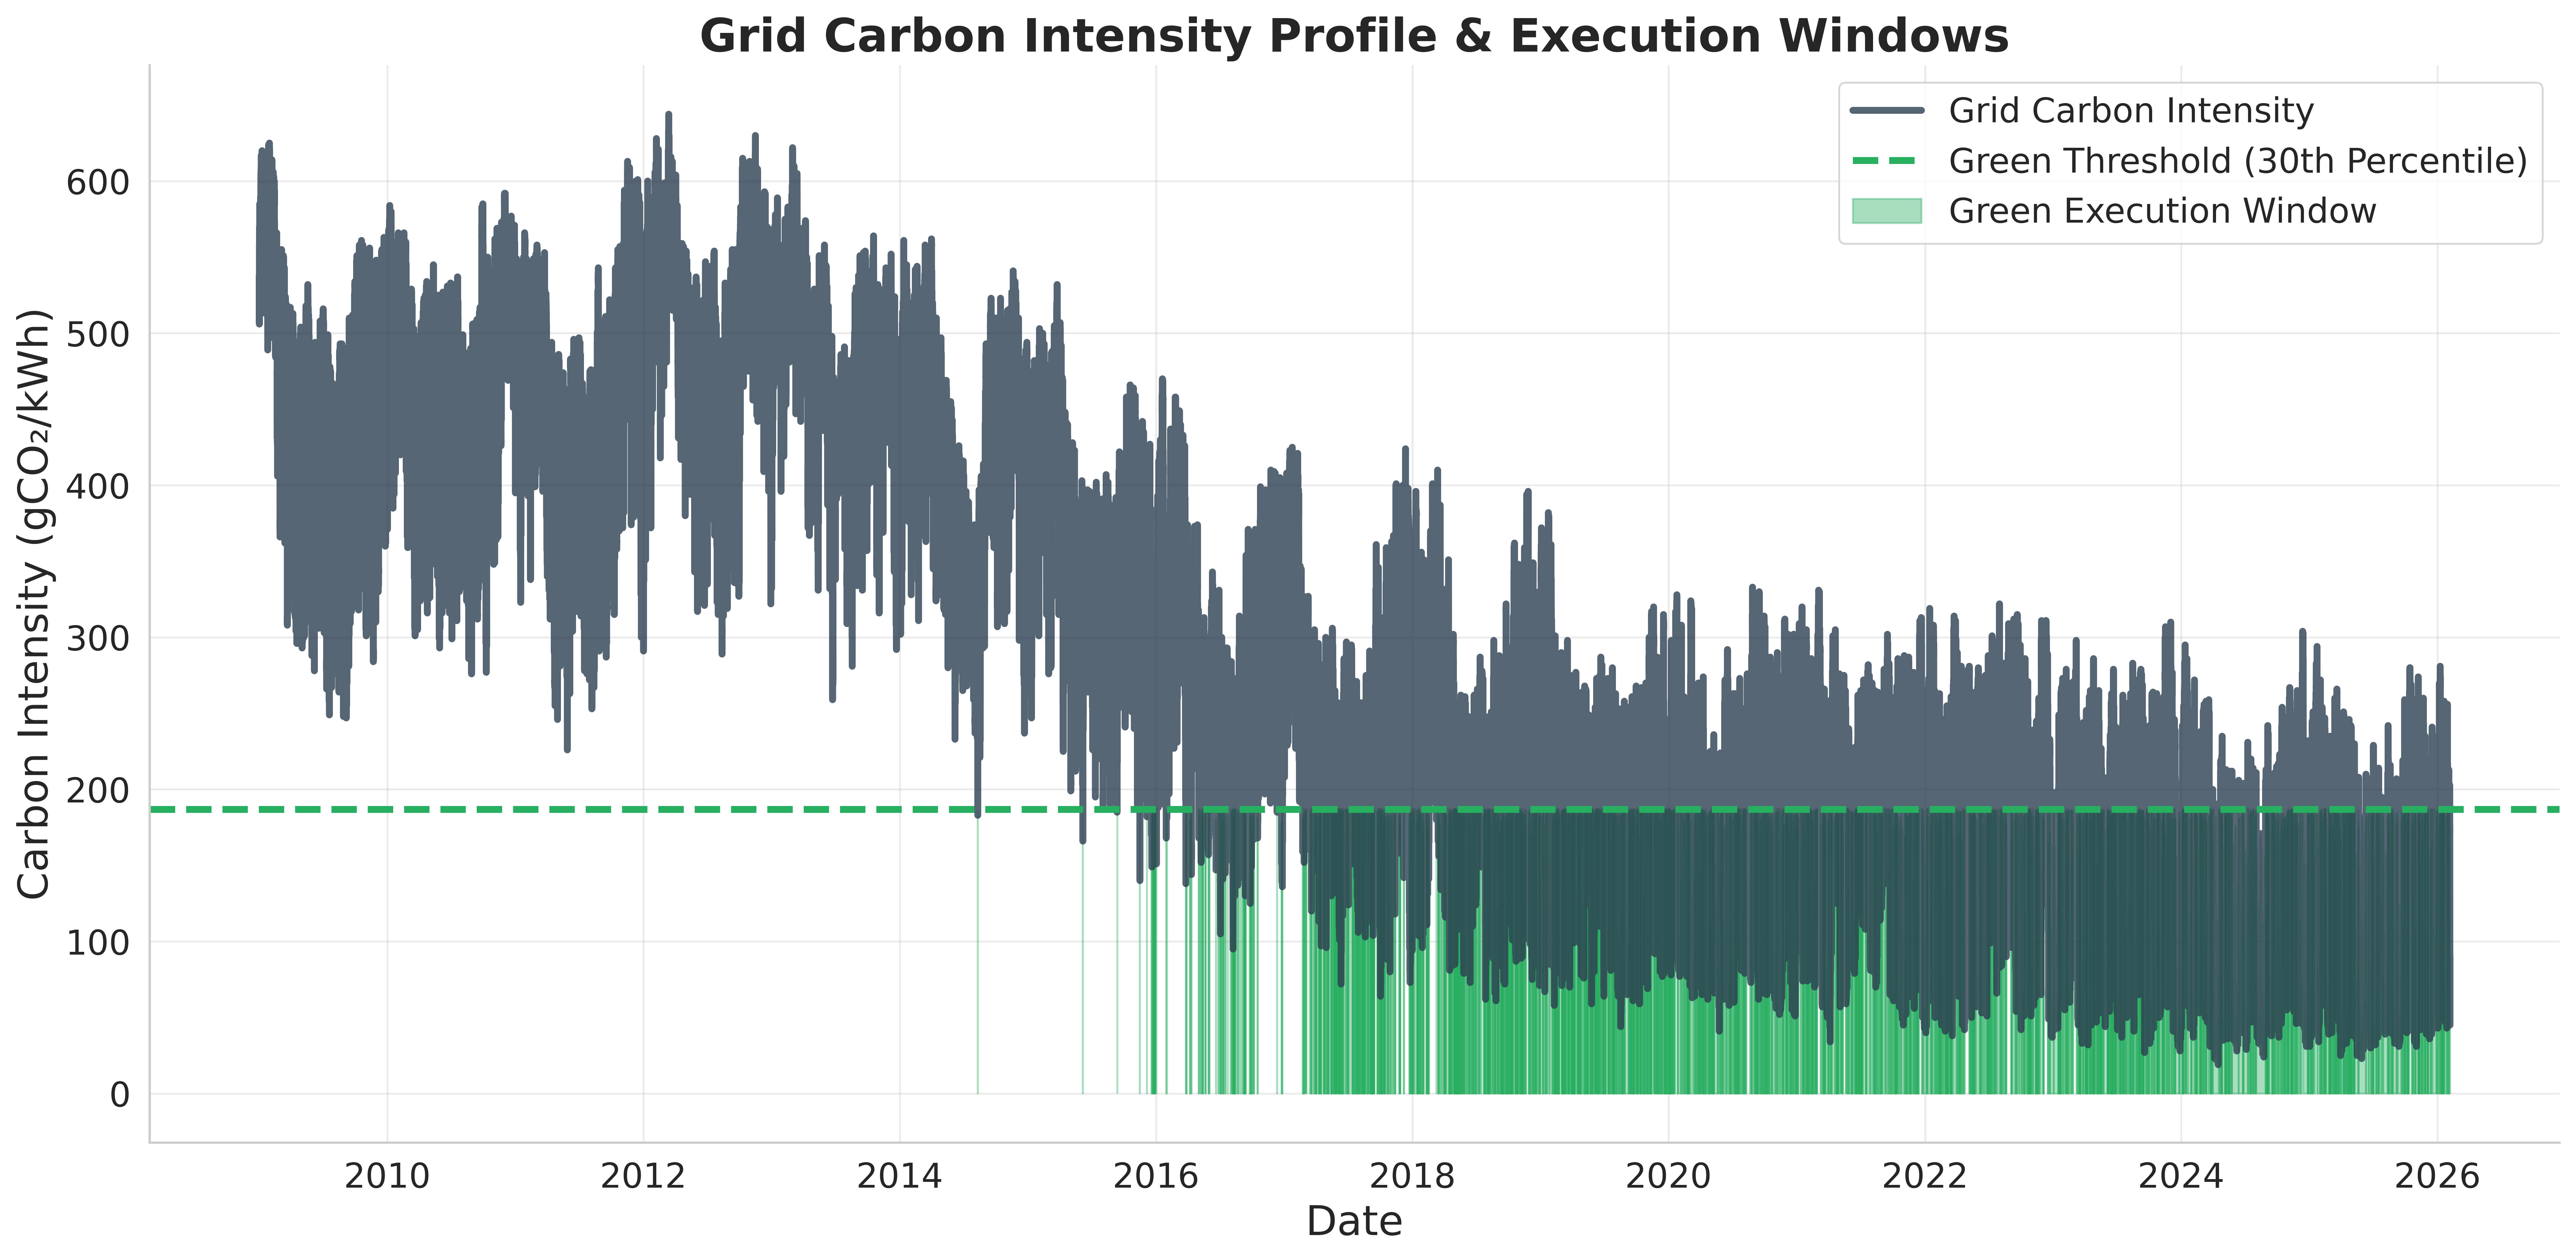

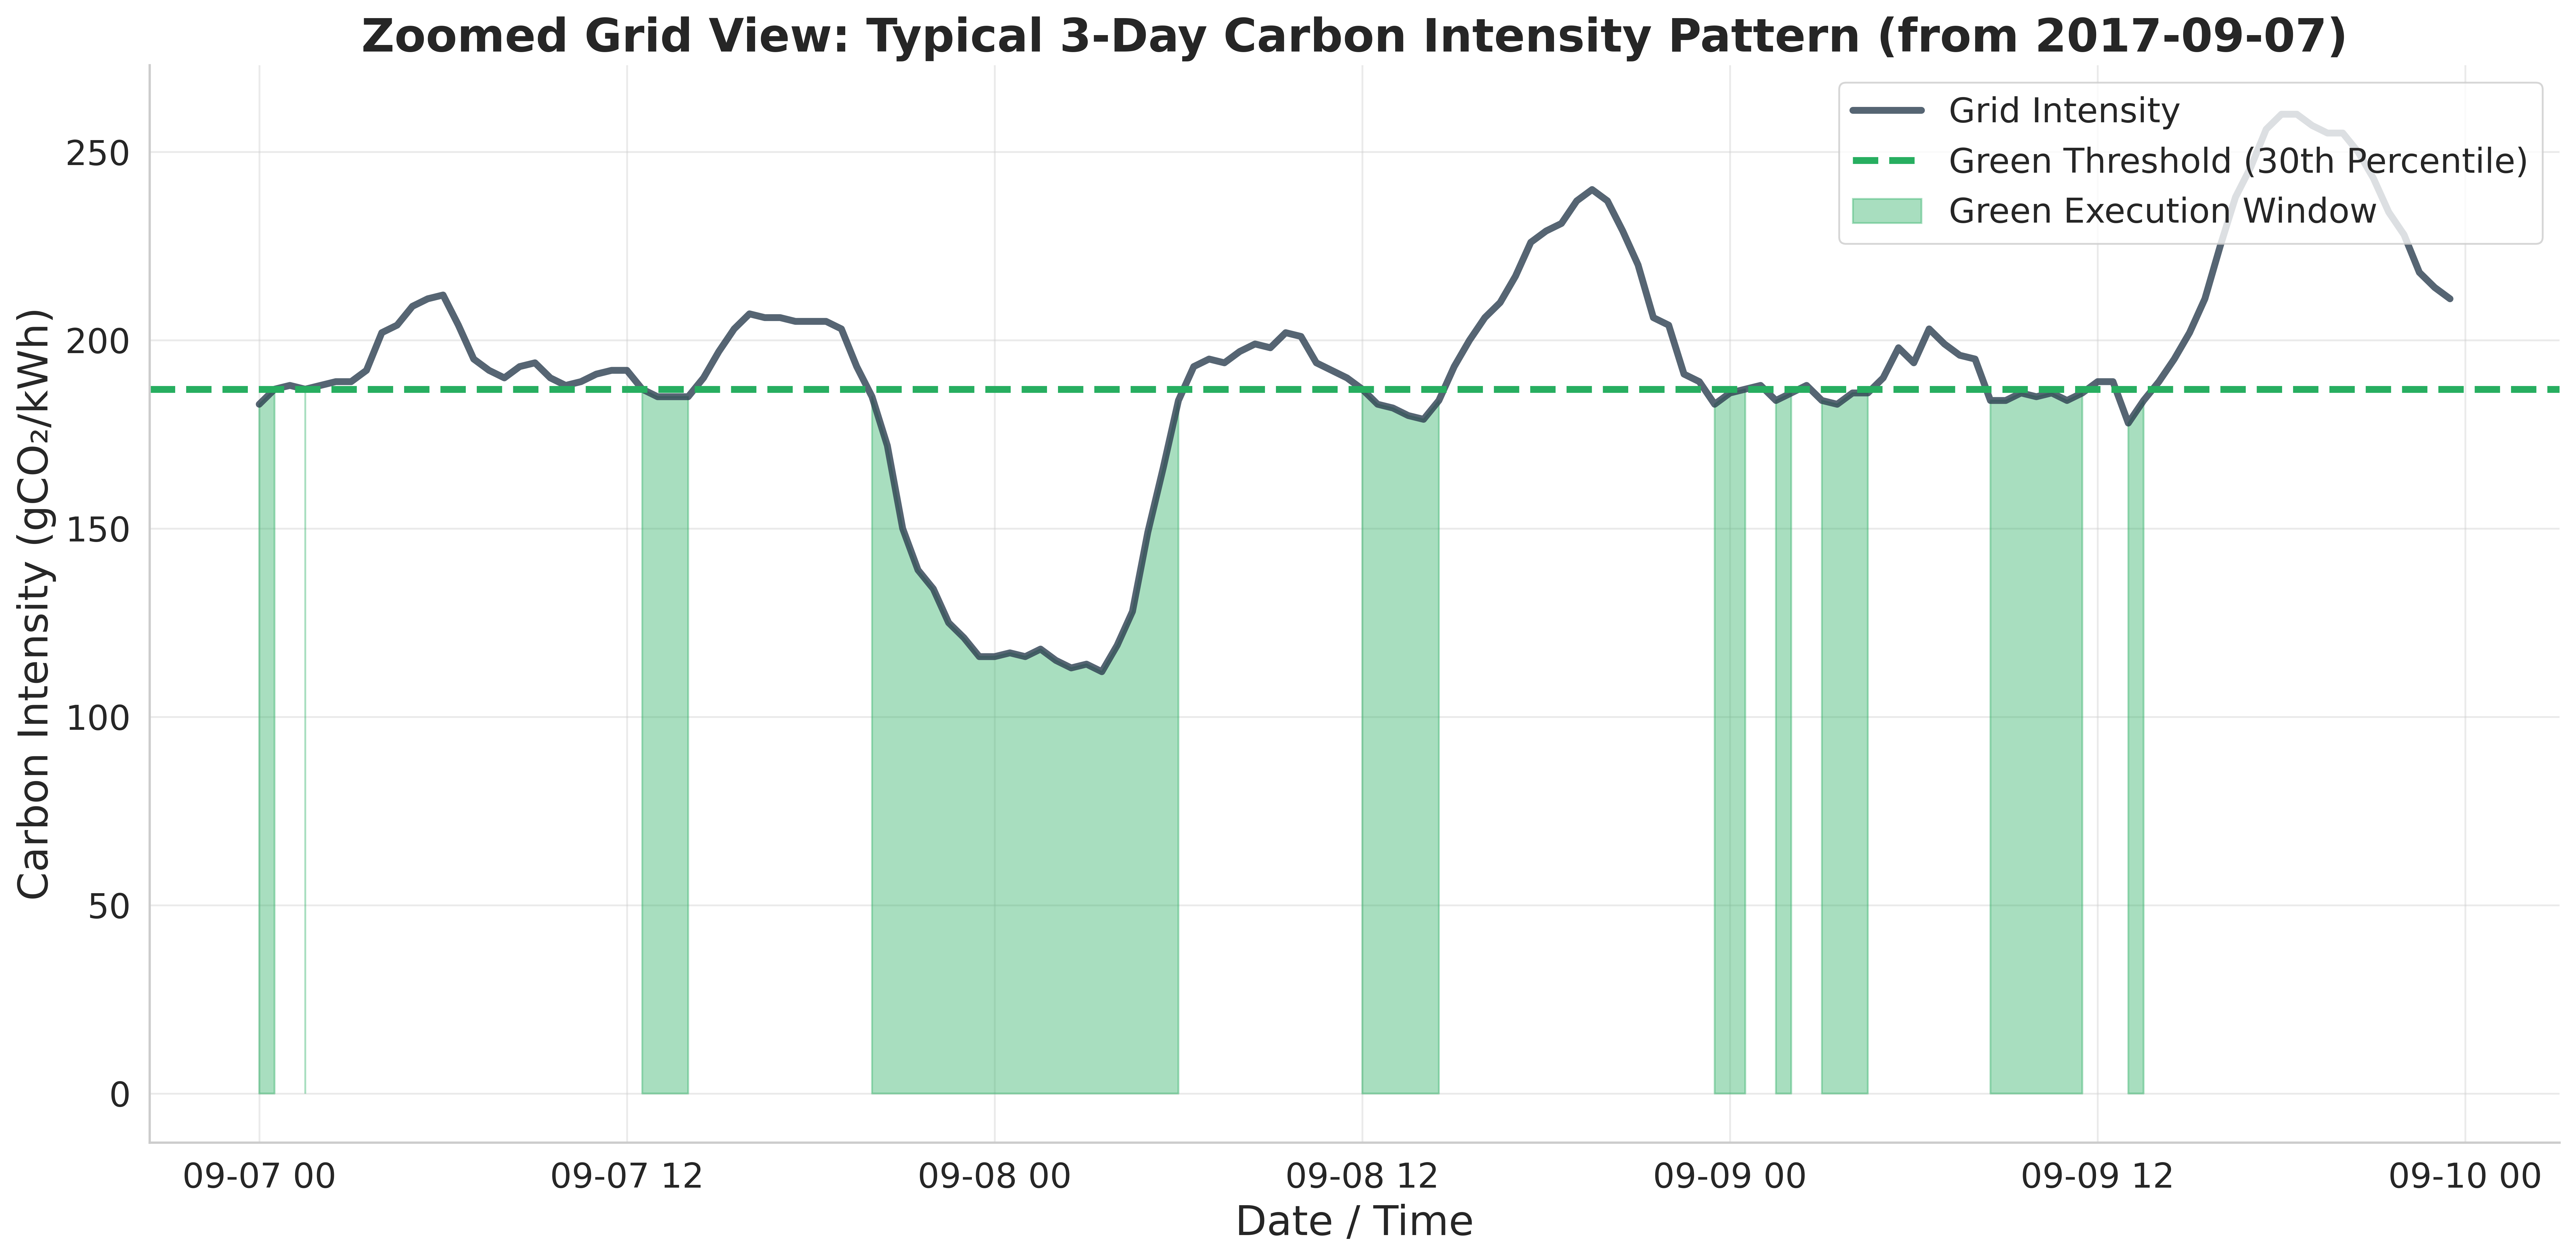

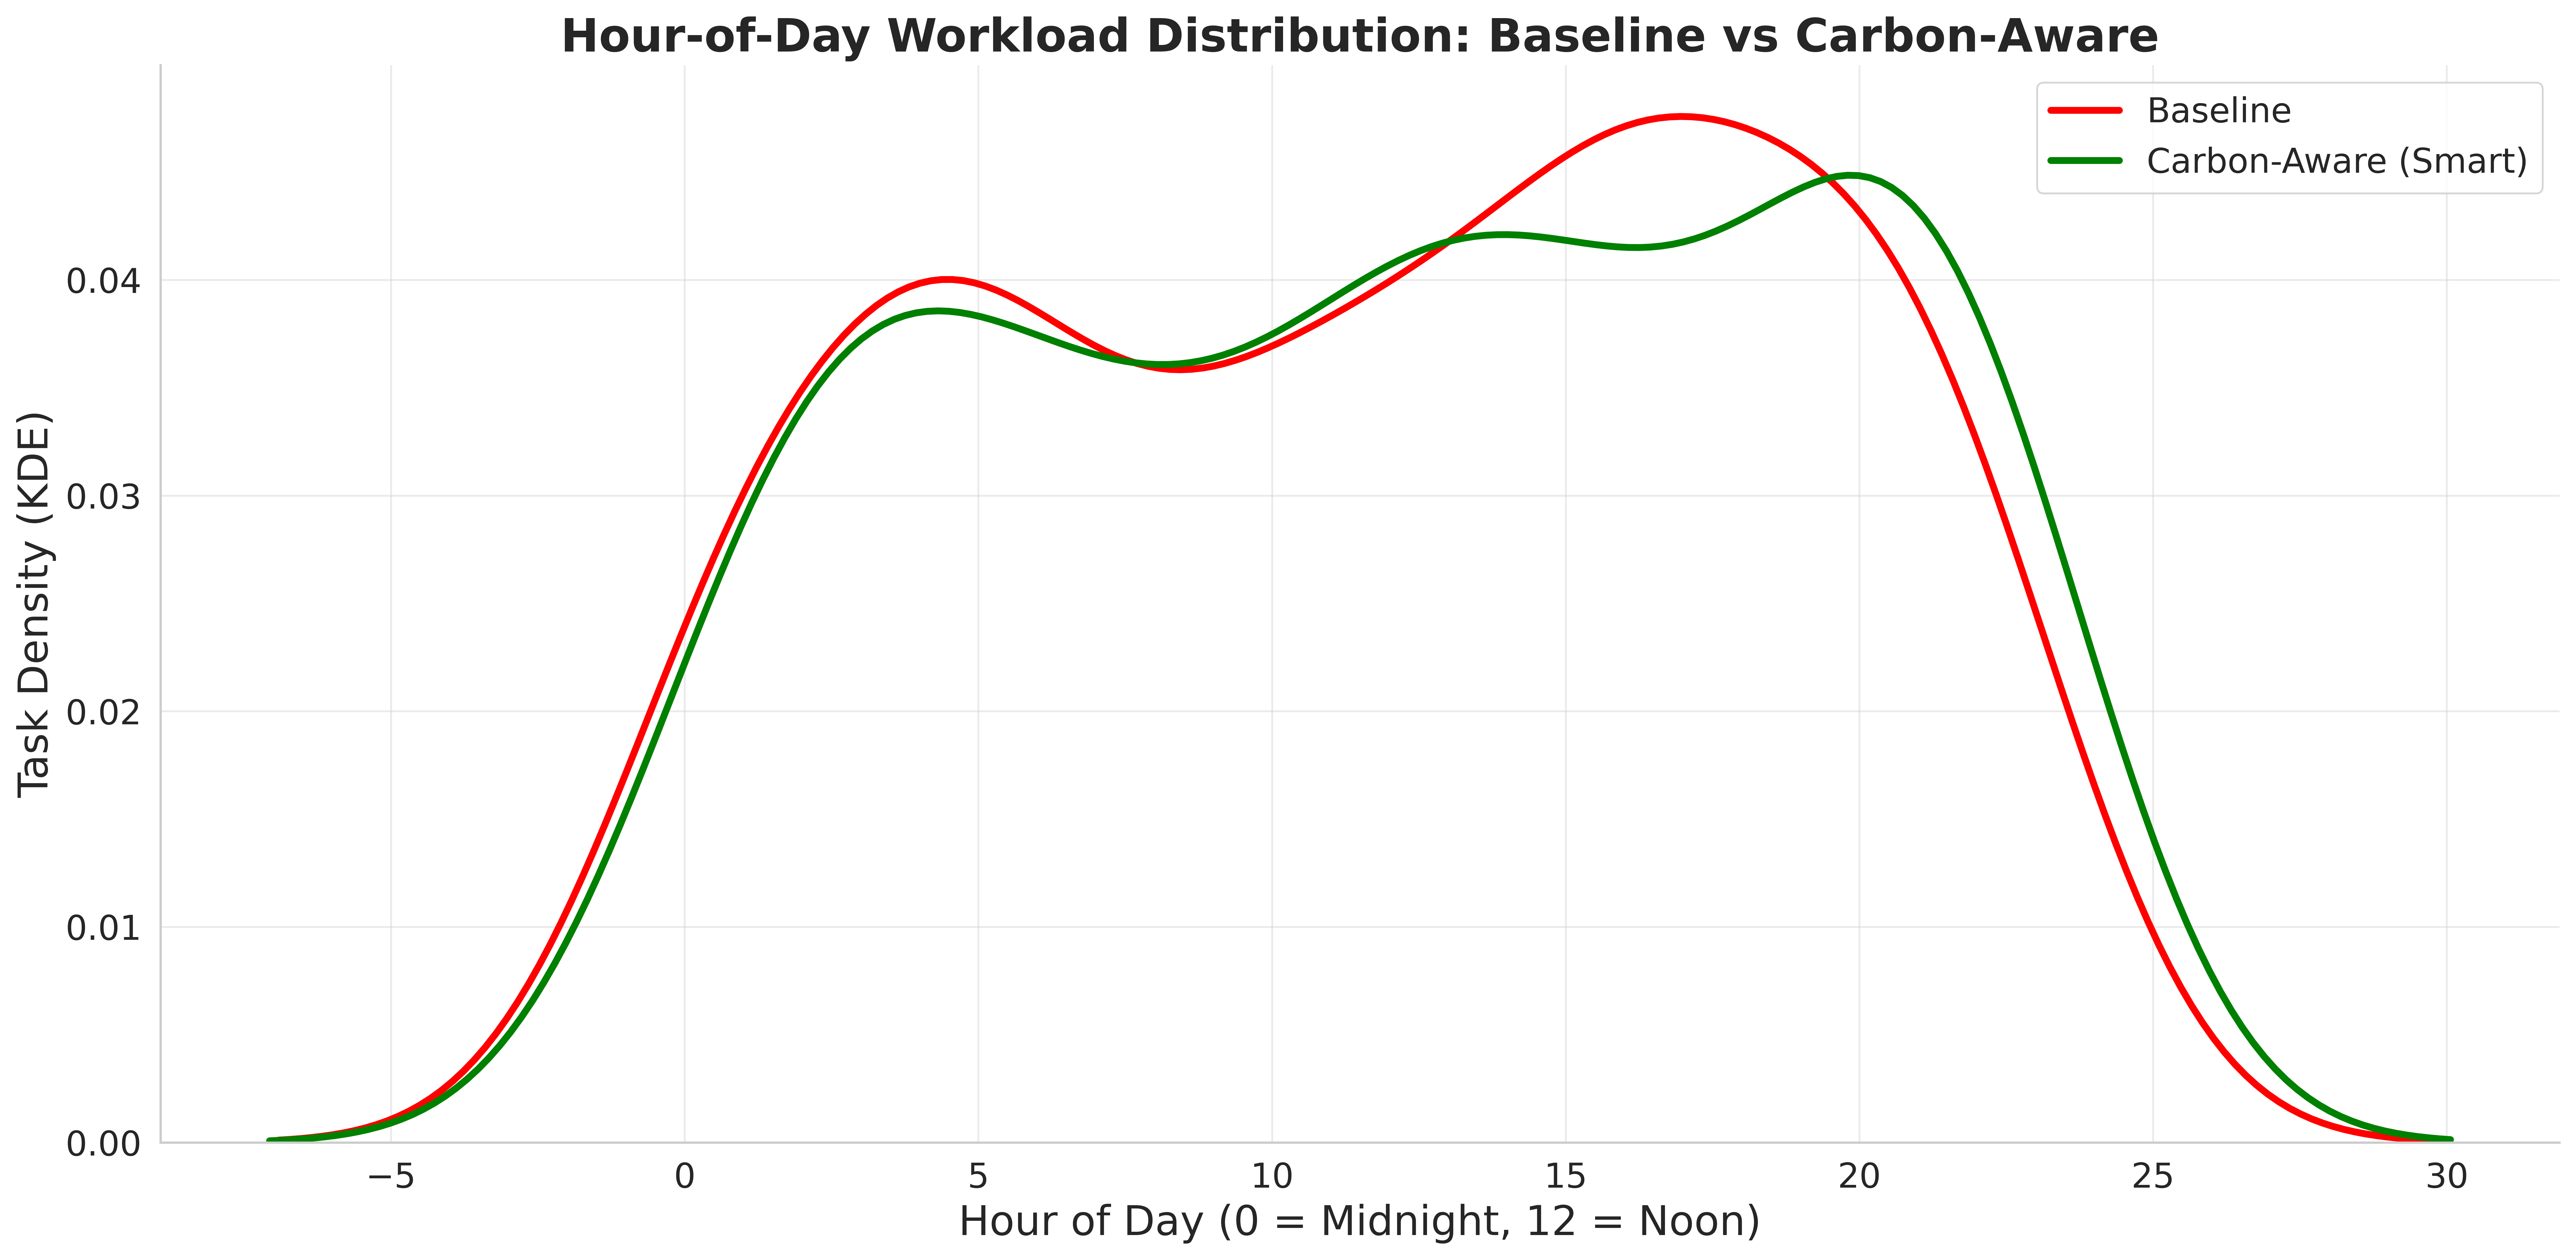

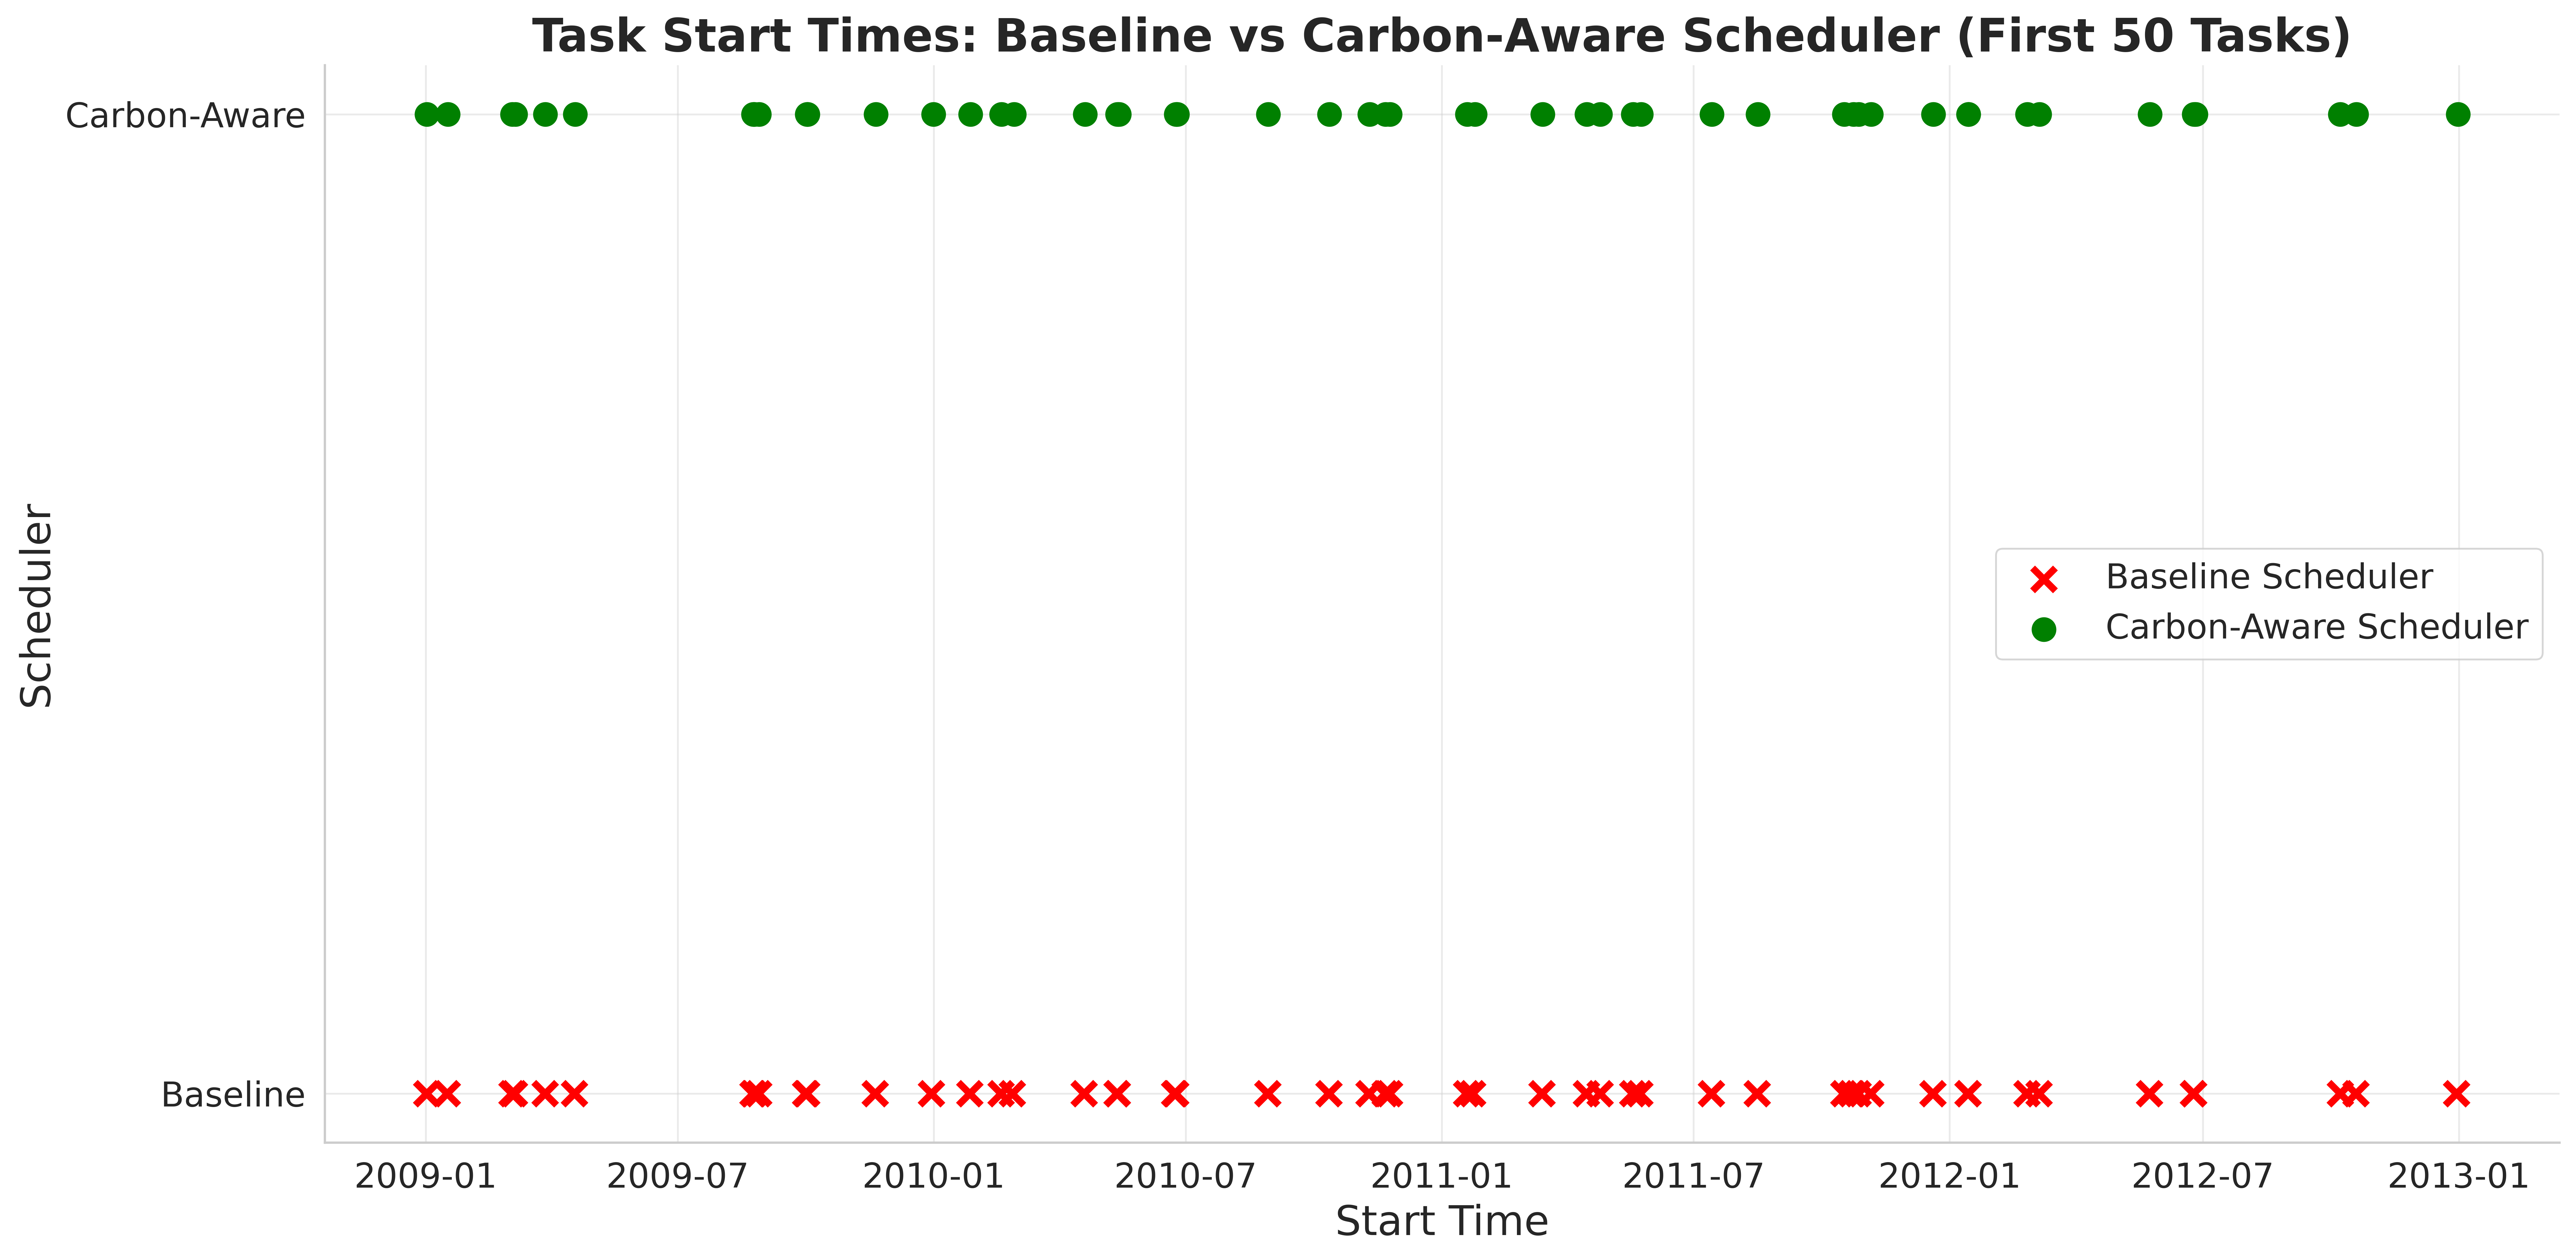

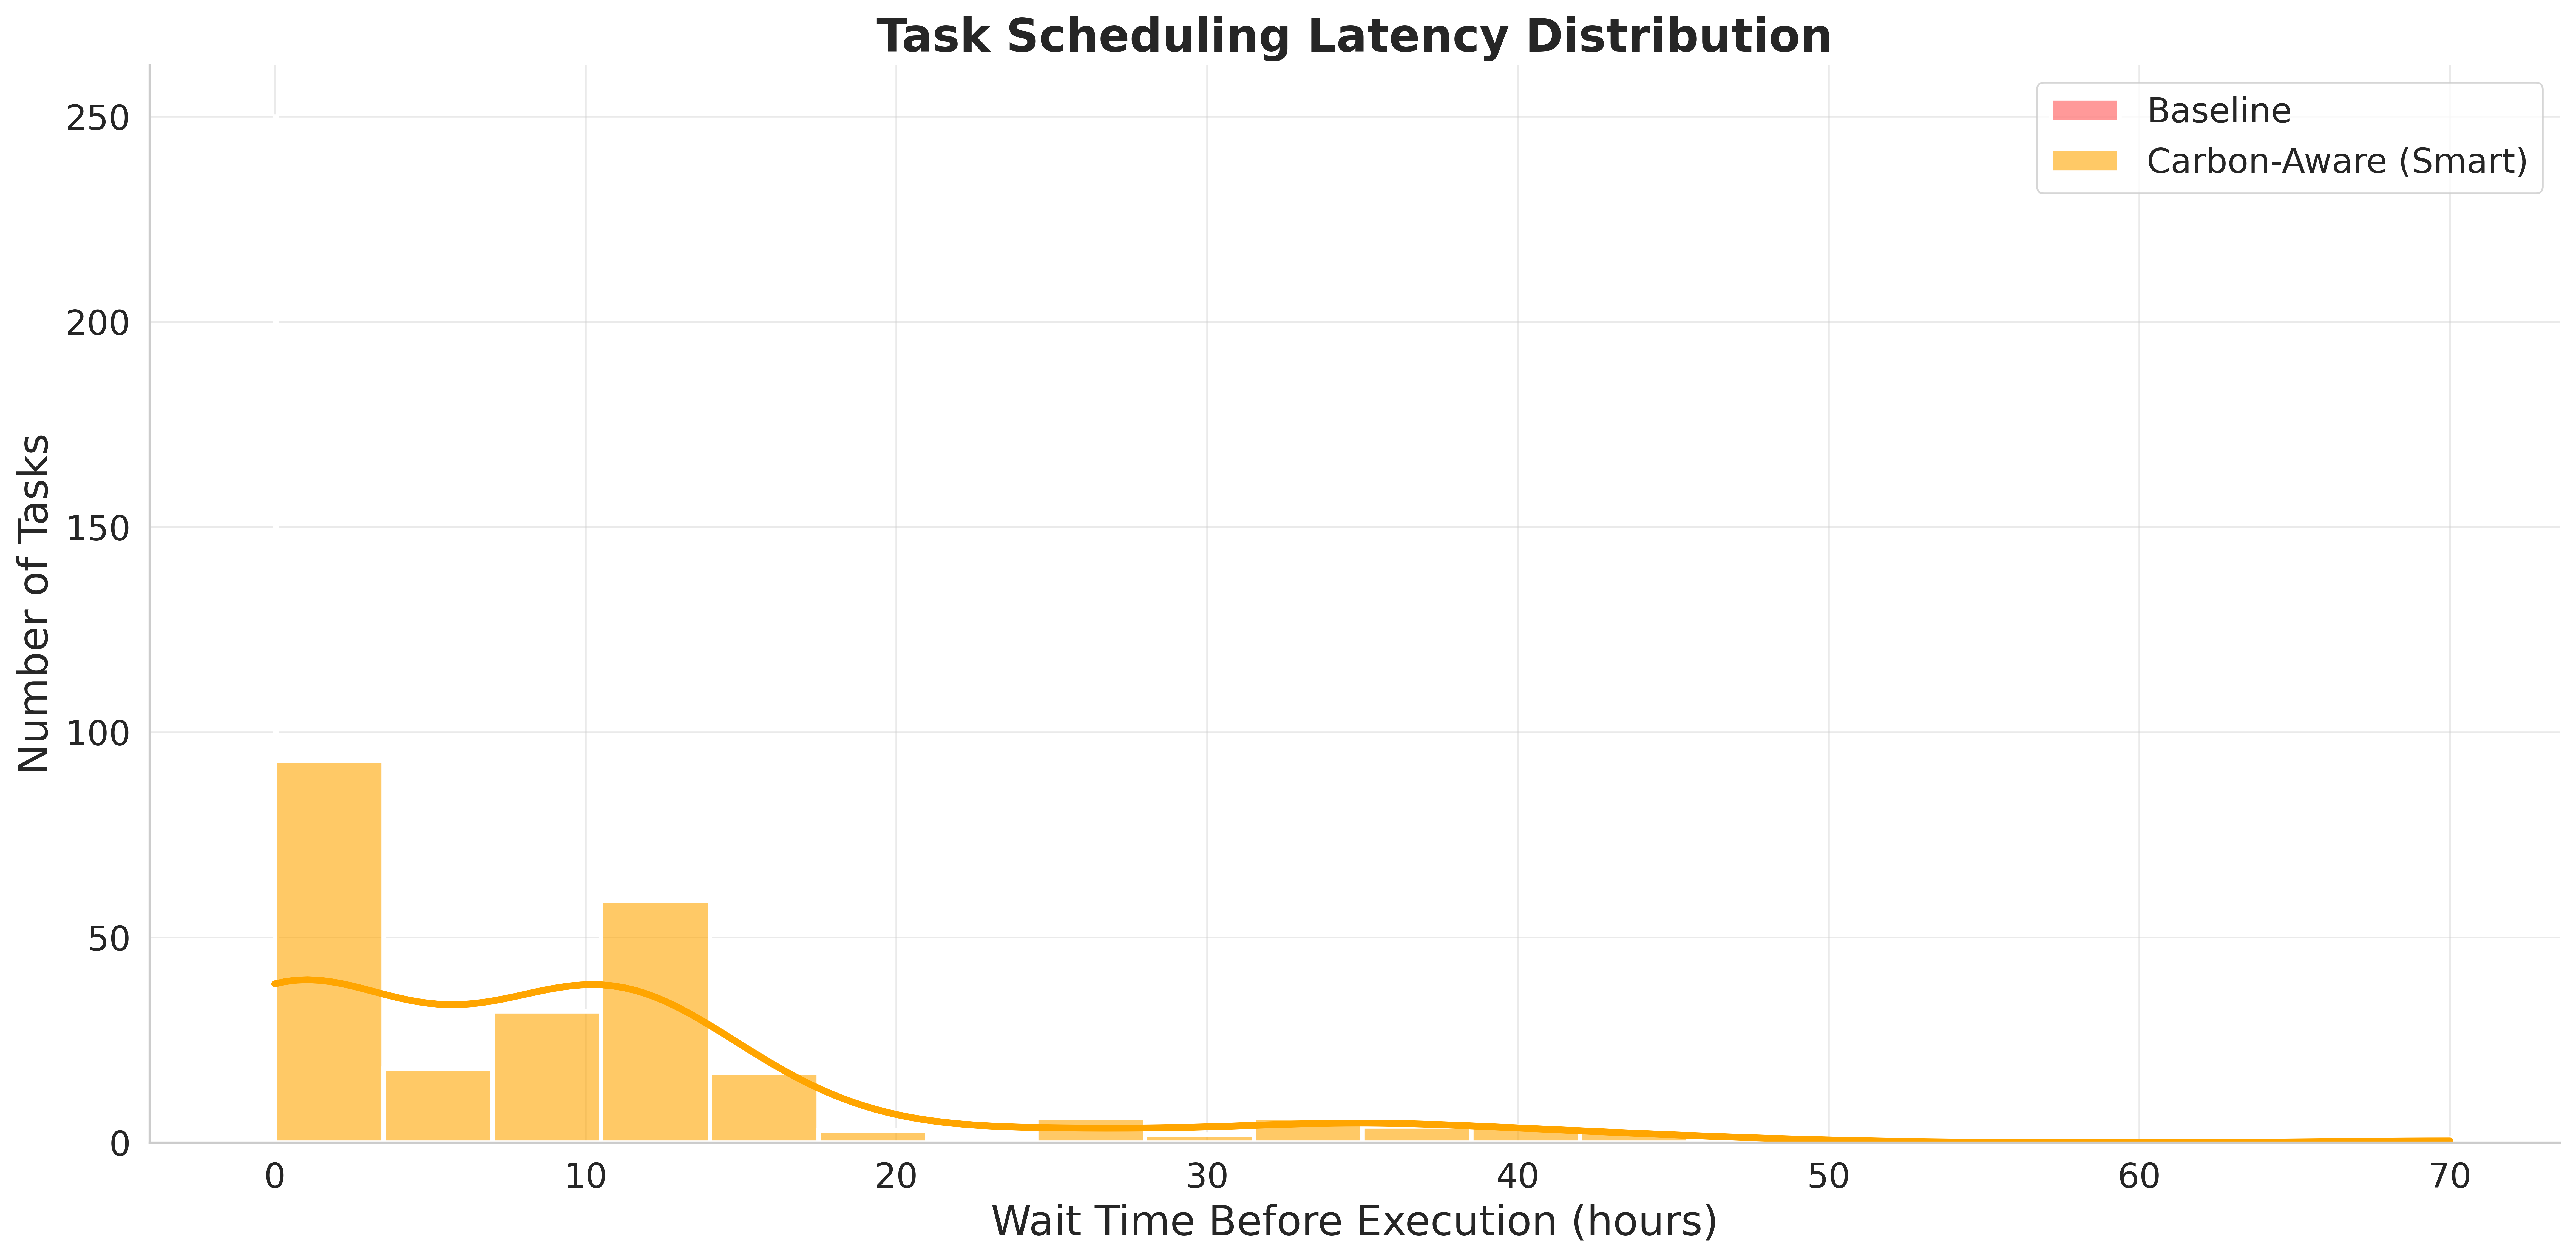

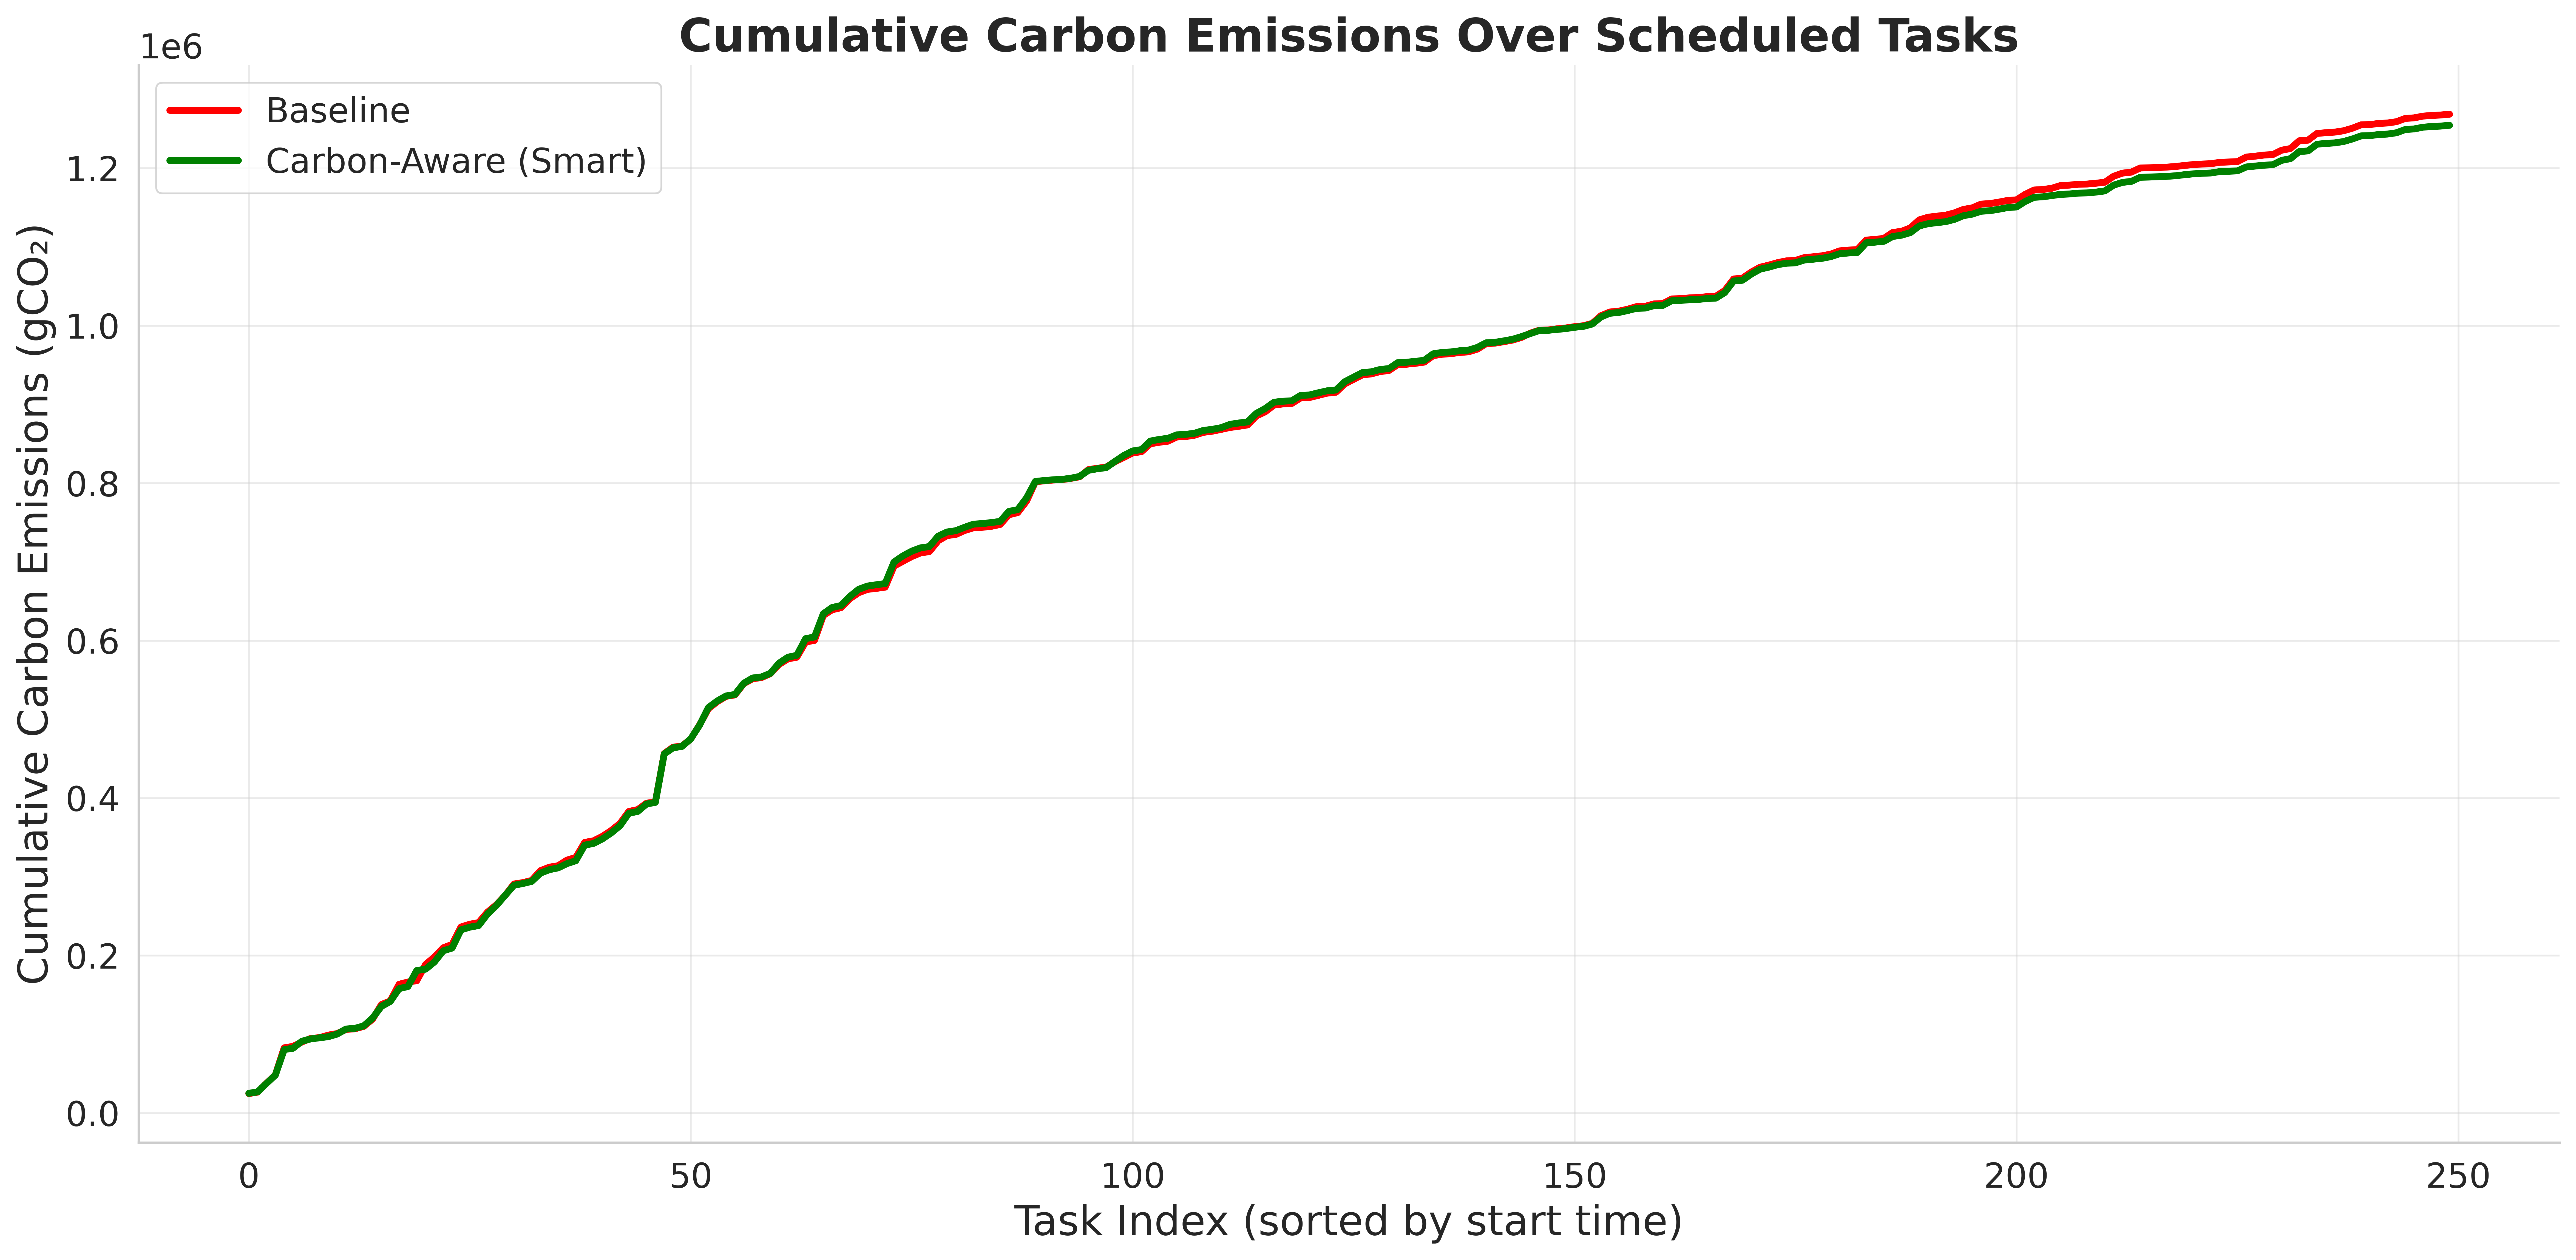

In [23]:
# Create a results folder at the root of the repository
os.makedirs('../results', exist_ok=True)

# Set standard size 
indiv_figsize = (16, 8)

# FIGURE 2: GRID PROFILE WITH GREEN WINDOWS 
plt.figure(figsize=indiv_figsize)
threshold = np.percentile(clean_df['carbon_intensity'], 30)

plt.plot(clean_df.index, clean_df['carbon_intensity'], color='#2c3e50', alpha=0.8, label='Grid Carbon Intensity', linewidth=3)
plt.axhline(threshold, color='#27ae60', linestyle='--', linewidth=3, label='Green Threshold (30th Percentile)')
plt.fill_between(clean_df.index, 0, clean_df['carbon_intensity'],
                where=(clean_df['carbon_intensity'] <= threshold),
                color='#27ae60', alpha=0.4, label='Green Execution Window')

plt.title('Grid Carbon Intensity Profile & Execution Windows')
plt.xlabel('Date')
plt.ylabel('Carbon Intensity (gCO₂/kWh)')
plt.legend(loc='upper right', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig2_grid_profile.png', dpi=600, bbox_inches='tight')
plt.show()

# FIGURE 3: ZOOMED VIEW 
plt.figure(figsize=indiv_figsize)
window_size = 144
best_start_idx = 0
max_crossings = 0

for i in range(0, len(clean_df) - window_size, 48):
    window = clean_df.iloc[i : i+window_size]
    crossings = np.sum(np.diff((window['carbon_intensity'] > threshold).astype(int)) != 0)
    if crossings > max_crossings:
        max_crossings = crossings
        best_start_idx = i

view = clean_df.iloc[best_start_idx : best_start_idx + window_size]
start_date_str = view.index[0].strftime('%Y-%m-%d')

plt.plot(view.index, view['carbon_intensity'], color='#2c3e50', alpha=0.8, label='Grid Intensity', linewidth=3)
plt.axhline(threshold, color='#27ae60', linestyle='--', linewidth=3, label='Green Threshold (30th Percentile)')
plt.fill_between(view.index, 0, view['carbon_intensity'],
                where=(view['carbon_intensity'] <= threshold),
                color='#27ae60', alpha=0.4, label='Green Execution Window')

plt.title(f'Zoomed Grid View: Typical 3-Day Carbon Intensity Pattern (from {start_date_str})')
plt.xlabel('Date / Time')
plt.ylabel('Carbon Intensity (gCO₂/kWh)')
plt.legend(loc='upper right', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig3_zoomed_view.png', dpi=600, bbox_inches='tight')
plt.show()


# FIGURE 4: WORKLOAD SHIFT 
plt.figure(figsize=indiv_figsize)
sns.kdeplot([t.start_time.hour for t in results_naive], fill=False, color='red', label='Baseline', linewidth=3)
sns.kdeplot([t.start_time.hour for t in results_smart], fill=False, color='green', label='Carbon-Aware (Smart)', linewidth=3)
plt.title('Hour-of-Day Workload Distribution: Baseline vs Carbon-Aware')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Task Density (KDE)')
plt.legend(loc='upper right', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig4_workload_shift.png', dpi=600, bbox_inches='tight')
plt.show()


# FIGURE 5: SCATTER OF DECISIONS 
plt.figure(figsize=(16, 8))
n1 = min(50, len(results_naive))
n2 = min(50, len(results_smart))

plt.scatter([t.start_time for t in results_naive[:n1]], [1]*n1,
            color='red', marker='x', s=100, label='Baseline Scheduler')
plt.scatter([t.start_time for t in results_smart[:n2]], [2]*n2,
            color='green', marker='o', s=100, label='Carbon-Aware Scheduler')

plt.yticks([1, 2], ['Baseline', 'Carbon-Aware'])
plt.title('Task Start Times: Baseline vs Carbon-Aware Scheduler (First 50 Tasks)')
plt.xlabel('Start Time')
plt.ylabel('Scheduler')
plt.legend(loc='center right', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig5_scatter_decisions.png', dpi=600, bbox_inches='tight')
plt.show()


# FIGURE 6: LATENCY HISTOGRAM 
plt.figure(figsize=indiv_figsize)
sns.histplot([t.waited_hours for t in results_naive], kde=True, color='red', label='Baseline', alpha=0.4, linewidth=2, bins=20)
sns.histplot([t.waited_hours for t in results_smart], kde=True, color='orange', label='Carbon-Aware (Smart)', alpha=0.6, linewidth=2, bins=20)
plt.title('Task Scheduling Latency Distribution')
plt.xlabel('Wait Time Before Execution (hours)')
plt.ylabel('Number of Tasks')
plt.legend(loc='upper right', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig6_latency_histogram.png', dpi=600, bbox_inches='tight')
plt.show()

# FIGURE 7: CUMULATIVE EMISSIONS 
plt.figure(figsize=indiv_figsize)
plt.plot(cum_naive, label='Baseline', color='red', linewidth=3)
plt.plot(cum_smart, label='Carbon-Aware (Smart)', color='green', linewidth=3)
plt.title('Cumulative Carbon Emissions Over Scheduled Tasks')
plt.xlabel('Task Index (sorted by start time)')
plt.ylabel('Cumulative Carbon Emissions (gCO₂)')
plt.legend(loc='upper left', fontsize=15)
plt.tight_layout()
plt.savefig('../results/fig7_cumulative_emissions.png', dpi=600, bbox_inches='tight')
plt.show()




